<a href="https://colab.research.google.com/github/annajoby123/fruits360-streamlit/blob/main/Fruits360_Classifier1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def find_dataset_root(search_root="/content"):
    """Walk the filesystem looking for a folder that contains both
    a Training/train split and a Test/test split (case-insensitive)."""
    for root, dirs, files in os.walk(search_root):
        lower_dirs = {d.lower(): d for d in dirs}
        has_train = "training" in lower_dirs or "train" in lower_dirs
        has_test = "test" in lower_dirs or "testing" in lower_dirs
        if has_train and has_test:
            train_name = lower_dirs.get("training", lower_dirs.get("train"))
            test_name = lower_dirs.get("test", lower_dirs.get("testing"))
            return root, train_name, test_name
    return None, None, None

BASE_DIR, train_name, test_name = find_dataset_root("/content")

if BASE_DIR is None:
    print("Dataset not found locally - downloading Fruits-360 via kagglehub...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub
    downloaded_path = kagglehub.dataset_download("moltean/fruits")
    print("Downloaded to:", downloaded_path)
    BASE_DIR, train_name, test_name = find_dataset_root(downloaded_path)

if BASE_DIR is None:
    raise FileNotFoundError(
        "Still could not locate a Training/Test folder structure. "
        "Print the downloaded_path contents (e.g. `!find <path> -maxdepth 3`) "
        "and set TRAIN_DIR / TEST_DIR manually below."
    )

TRAIN_DIR = os.path.join(BASE_DIR, train_name)
TEST_DIR = os.path.join(BASE_DIR, test_name)

# Some Fruits-360 exports have a handful of classes present in only one split.
# We keep only classes that exist in BOTH Training and Test so every generator
# below stays perfectly aligned (same classes, same index mapping).
train_classes = set(os.listdir(TRAIN_DIR))
test_classes = set(os.listdir(TEST_DIR))

only_in_train = sorted(train_classes - test_classes)
only_in_test = sorted(test_classes - train_classes)

class_names = sorted(train_classes & test_classes)
NUM_CLASSES = len(class_names)

print(f"Dataset found at: {BASE_DIR}")
print(f"Training folder: {TRAIN_DIR}")
print(f"Test folder: {TEST_DIR}")
print(f"Number of usable classes (present in both splits): {NUM_CLASSES}")
print("Sample classes:", class_names[:10])

if only_in_train:
    print(f"\nNote: {len(only_in_train)} class(es) found only in Training and skipped: {only_in_train[:10]}{' ...' if len(only_in_train) > 10 else ''}")
if only_in_test:
    print(f"Note: {len(only_in_test)} class(es) found only in Test and skipped: {only_in_test[:10]}{' ...' if len(only_in_test) > 10 else ''}")


Dataset not found locally - downloading Fruits-360 via kagglehub...
Using Colab cache for faster access to the 'fruits' dataset.
Downloaded to: /kaggle/input/fruits
Dataset found at: /kaggle/input/fruits/fruits-360_100x100/fruits-360
Training folder: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test folder: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test
Number of usable classes (present in both splits): 259
Sample classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']

Note: 1 class(es) found only in Training and skipped: ['BlackBerry 4']
Note: 1 class(es) found only in Test and skipped: ['Blackberry 4']


Total training images: 136782
Total test images: 45579

Images per class (training) - summary stats:
count    259.000000
mean     528.115830
std      172.380242
min      144.000000
25%      451.000000
50%      490.000000
75%      696.000000
max      984.000000
dtype: float64


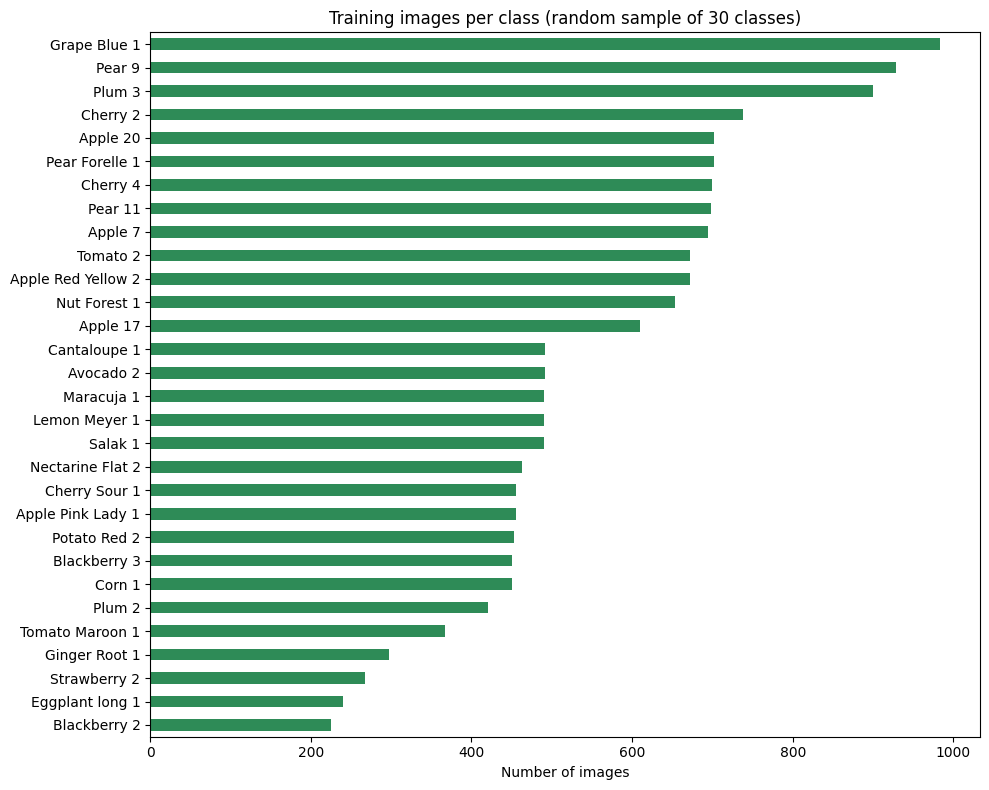

In [ ]:
def count_images(directory, classes):
    counts = {}
    for c in classes:
        class_dir = os.path.join(directory, c)
        counts[c] = len(os.listdir(class_dir)) if os.path.isdir(class_dir) else 0
    return pd.Series(counts)

train_counts = count_images(TRAIN_DIR, class_names)
test_counts = count_images(TEST_DIR, class_names)

print("Total training images:", train_counts.sum())
print("Total test images:", test_counts.sum())
print("\nImages per class (training) - summary stats:")
print(train_counts.describe())

# Distribution across a sample of 30 classes (130+ classes won't fit legibly on one axis)
sample_classes = train_counts.sample(30, random_state=SEED).sort_values()
plt.figure(figsize=(10, 8))
sample_classes.plot(kind="barh", color="seagreen")
plt.title("Training images per class (random sample of 30 classes)")
plt.xlabel("Number of images")
plt.tight_layout()
plt.show()


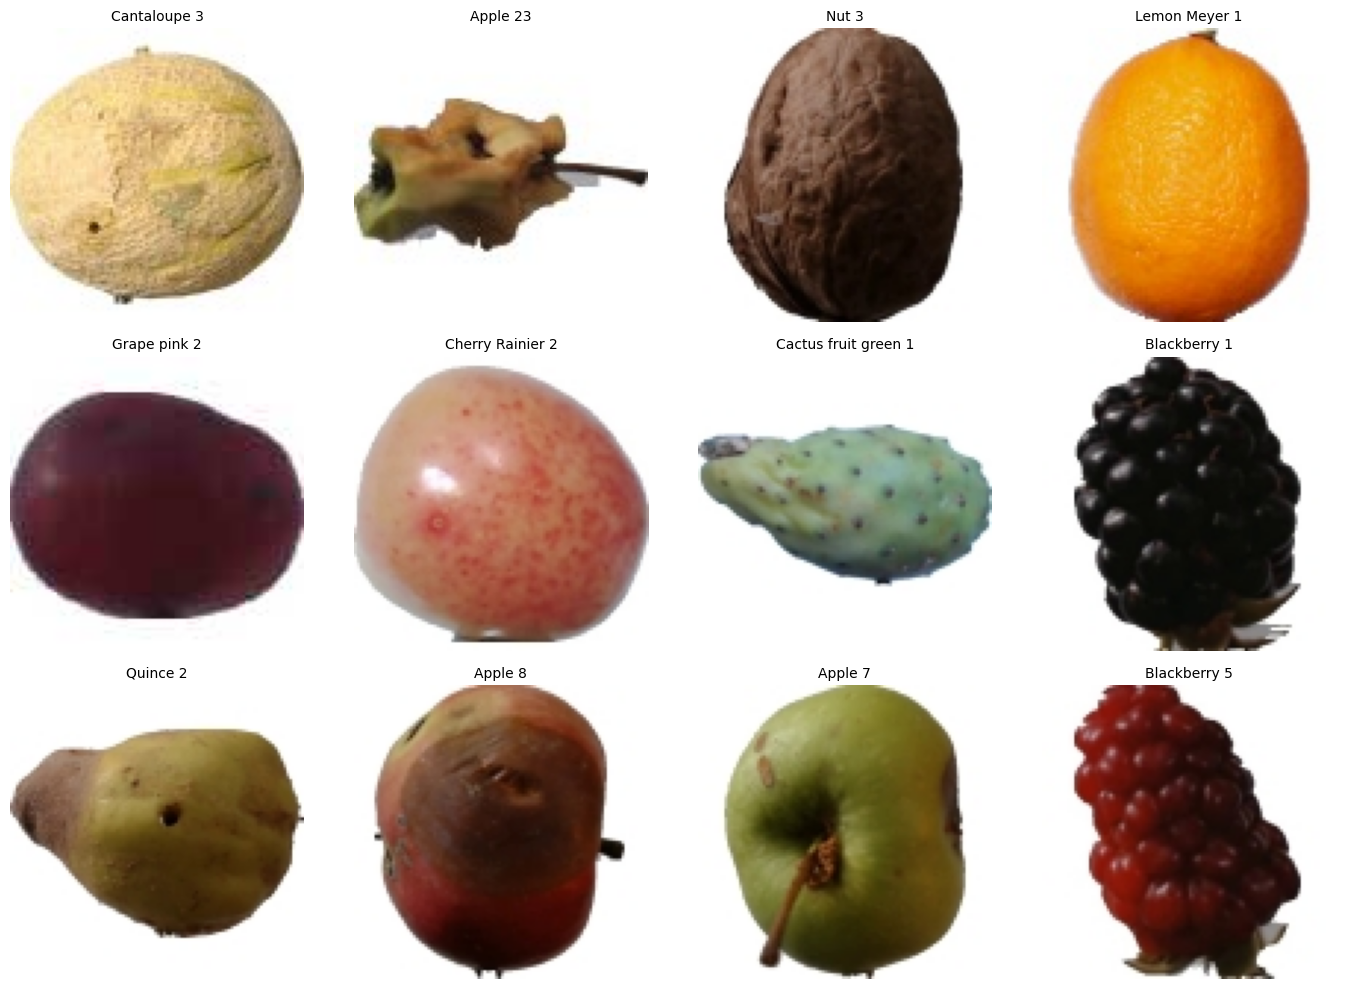

In [ ]:
def show_sample_grid(directory, classes, n=12):
    chosen = random.sample(classes, n)
    plt.figure(figsize=(14, 10))
    for i, c in enumerate(chosen):
        class_dir = os.path.join(directory, c)
        img_name = random.choice(os.listdir(class_dir))
        img = keras.utils.load_img(os.path.join(class_dir, img_name))
        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(c, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_grid(TRAIN_DIR, class_names)


In [ ]:
IMG_SIZE = (64, 64)   # downsized from the native 100x100 for faster training; still plenty for Fruits-360
BATCH_SIZE = 128       # larger batch = fewer steps/epoch on a GPU

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=class_names,       # lock class list/order so train/val/test agree
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    classes=class_names,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

# Sanity check: class index mapping is identical across generators
assert train_generator.class_indices == val_generator.class_indices == test_generator.class_indices
print("Classes are consistently indexed across train/val/test generators.")


Found 116395 images belonging to 259 classes.
Found 20387 images belonging to 259 classes.
Found 45579 images belonging to 259 classes.
Classes are consistently indexed across train/val/test generators.


In [ ]:
def build_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="fruits360_cnn_fast")
    return model

cnn_model = build_cnn(IMG_SIZE + (3,), NUM_CLASSES)
cnn_model.summary()


Model: "fruits360_cnn_fast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 259)            │        33,411 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,067 (562.76 KB)

 Trainable params: 143,619 (561.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
    ModelCheckpoint("best_fruits360_cnn.keras", monitor="val_accuracy", save_best_only=True),
]


In [ ]:
EPOCHS = 12

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 728s 791ms/step - accuracy: 0.6277 - loss: 1.3620 - val_accuracy: 0.7765 - val_loss: 0.6231 - learning_rate: 0.0010
Epoch 2/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 287s 315ms/step - accuracy: 0.9136 - loss: 0.2602 - val_accuracy: 0.8535 - val_loss: 0.4104 - learning_rate: 0.0010
Epoch 3/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 290s 319ms/step - accuracy: 0.9506 - loss: 0.1462 - val_accuracy: 0.8327 - val_loss: 0.5048 - learning_rate: 0.0010
Epoch 4/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 290s 318ms/step - accuracy: 0.9742 - loss: 0.0774 - val_accuracy: 0.9412 - val_loss: 0.1777 - learning_rate: 5.0000e-04
Epoch 5/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 289s 318ms/step - accuracy: 0.9765 - loss: 0.0678 - val_accuracy: 0.9554 - val_loss: 0.1254 - learning_rate: 5.0000e-04
Epoch 6/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 285s 314ms/step - accuracy: 0.9794 - loss: 0.0591 - val_accuracy: 0.9633 - val_loss: 0.1029 - learning_rate: 5.0000e-04
Epoch 7/12
910/910 ━━━━━━━━━━━━━━━━━━━━ 303s 333ms/s

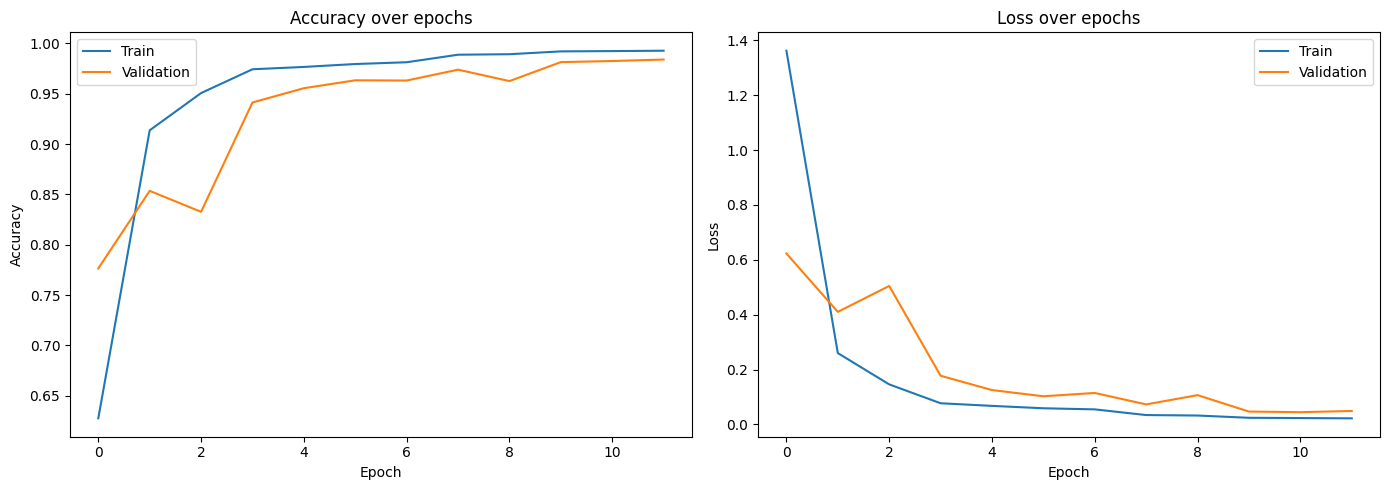

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


357/357 ━━━━━━━━━━━━━━━━━━━━ 239s 670ms/step - accuracy: 0.9021 - loss: 0.3710
Test loss: 0.3710
Test accuracy: 0.9021


In [ ]:
y_true = test_generator.classes
y_pred_probs = cnn_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

idx_to_class = {v: k for k, v in test_generator.class_indices.items()}

print(classification_report(
    y_true, y_pred,
    target_names=[idx_to_class[i] for i in range(NUM_CLASSES)],
    zero_division=0,
))


357/357 ━━━━━━━━━━━━━━━━━━━━ 57s 157ms/step
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.79      0.88       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       0.90      0.96      0.93       154
              Apple 13       1.00      0.97      0.99       235
              Apple 14       0.99      0.56      0.72       154
              Apple 17       1.00      1.00      1.00       201
              Apple 18       1.00      1.00      1.00       240
              Apple 19       0.88      1.00      0.93       241
              Apple 20       1.00      0.94      0.97       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       1.00      1.00      1.00       231
              Apple 23       0.91      0.99      0.95       156
               Apple 5       1.00      1.00      1.00      

Top 10 most-confused class pairs (true -> predicted : count):
  Dates 2 -> Carambola 3 : 240
  Cantaloupe 2 -> Cantaloupe 3 : 164
  Peach 6 -> Peach 5 : 144
  Cherry 2 -> Cherry 4 : 140
  Chestnut 1 -> Carambola 3 : 139
  Potato Red 2 -> Onion Red 1 : 135
  Pepper Yellow 1 -> Pepper Orange 2 : 125
  Onion White 1 -> Pineapple Mini 1 : 118
  Tomato 5 -> Tomato 1 : 102
  Peach 4 -> Apple 9 : 95


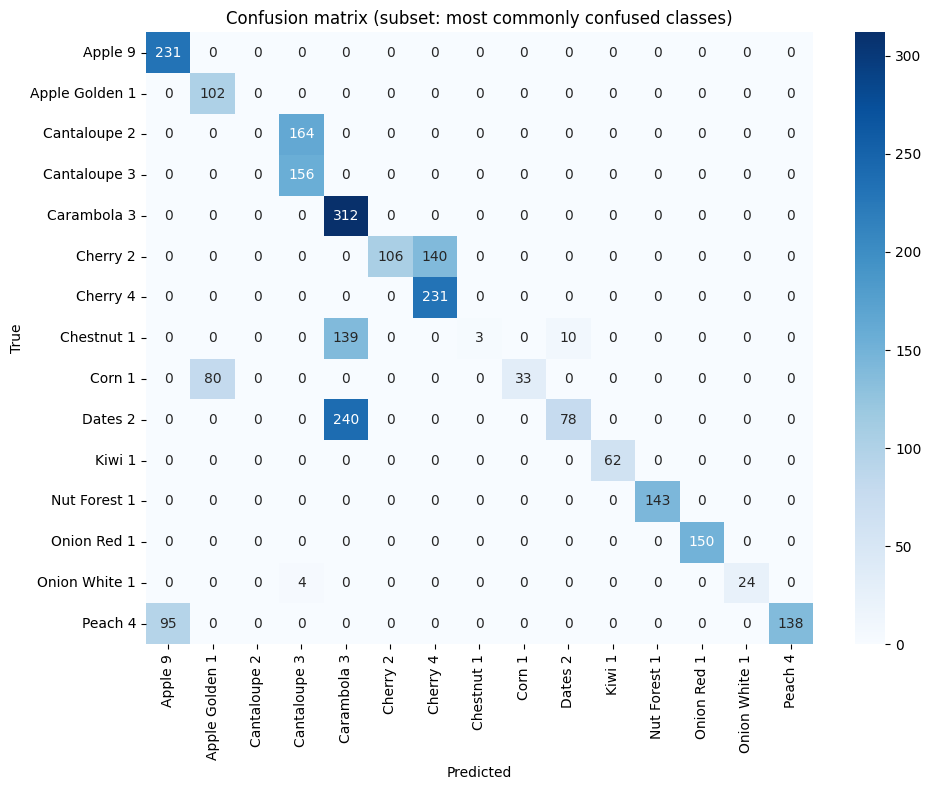

In [ ]:
cm = confusion_matrix(y_true, y_pred)

# Find the most-confused class pairs (excluding the diagonal)
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
confused_flat = [(idx_to_class[i], idx_to_class[j], cm_no_diag[i, j])
                  for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if cm_no_diag[i, j] > 0]
confused_flat.sort(key=lambda x: x[2], reverse=True)

print("Top 10 most-confused class pairs (true -> predicted : count):")
for true_c, pred_c, count in confused_flat[:10]:
    print(f"  {true_c} -> {pred_c} : {int(count)}")

# Heatmap of the 15 classes most involved in confusion
involved = set()
for true_c, pred_c, _ in confused_flat[:15]:
    involved.add(true_c)
    involved.add(pred_c)
involved = sorted(involved)[:15]
involved_idx = [test_generator.class_indices[c] for c in involved]

small_cm = cm[np.ix_(involved_idx, involved_idx)]

plt.figure(figsize=(10, 8))
sns.heatmap(small_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=involved, yticklabels=involved)
plt.title("Confusion matrix (subset: most commonly confused classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


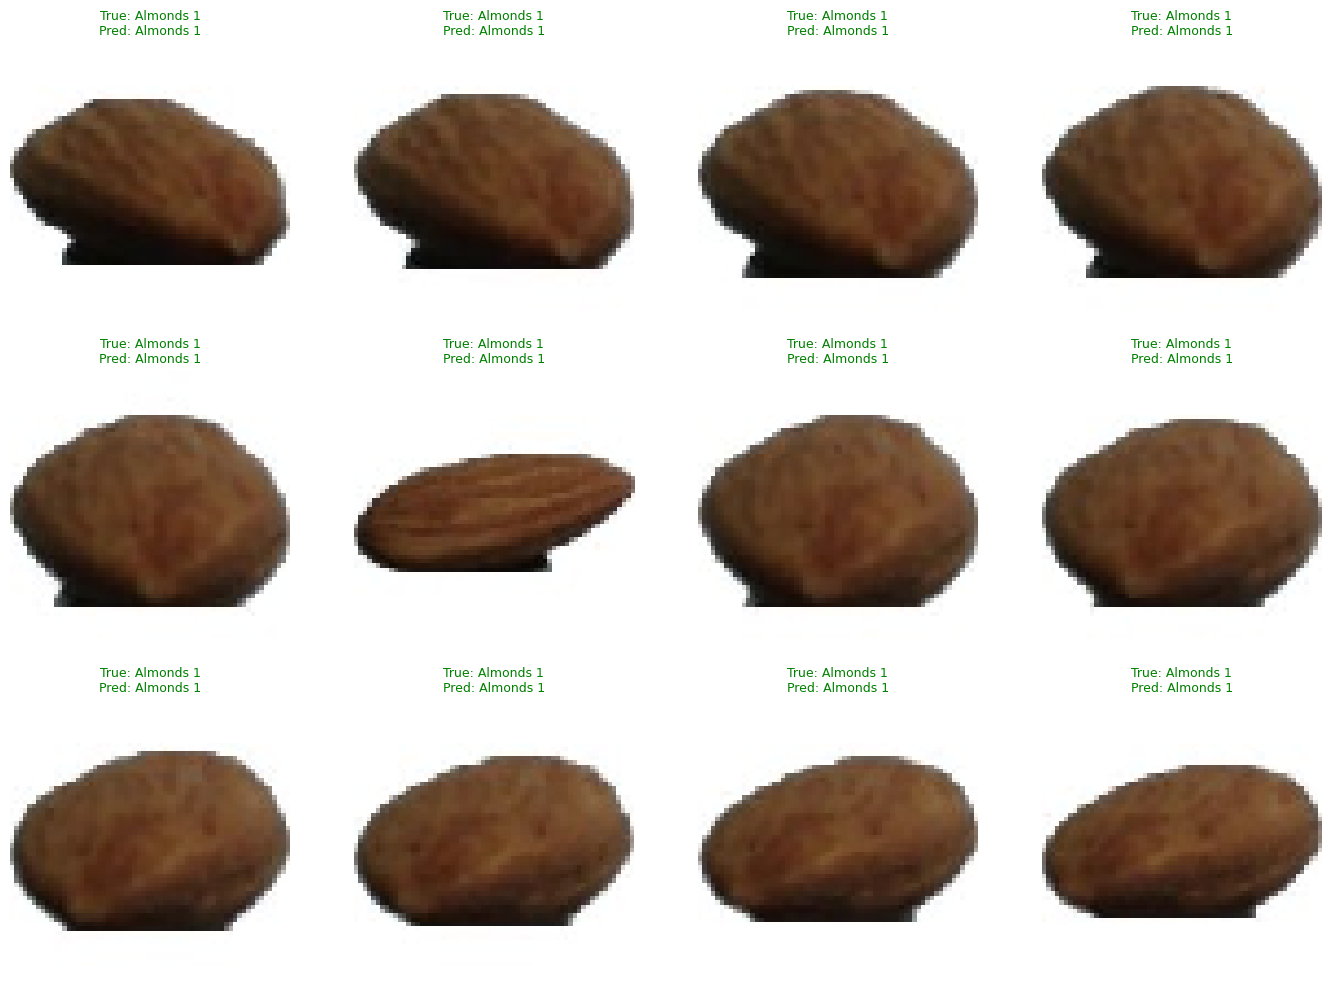

In [ ]:
test_generator.reset()
images, labels = next(test_generator)
preds = cnn_model.predict(images)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(14, 10))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    true_name = idx_to_class[true_labels[i]]
    pred_name = idx_to_class[pred_labels[i]]
    color = "green" if true_name == pred_name else "red"
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze backbone initially

transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="fruits360_mobilenetv2")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_callbacks = [
    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
]

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    callbacks=transfer_callbacks,
)

transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_generator)
print(f"MobileNetV2 test accuracy: {transfer_test_accuracy:.4f}")
print(f"Scratch CNN test accuracy: {test_accuracy:.4f}")


/tmp/ipykernel_1102/1672064461.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 305s 324ms/step - accuracy: 0.7466 - loss: 0.9580 - val_accuracy: 0.8654 - val_loss: 0.4233 - learning_rate: 0.0010
Epoch 2/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 280s 308ms/step - accuracy: 0.9068 - loss: 0.2816 - val_accuracy: 0.8789 - val_loss: 0.3835 - learning_rate: 0.0010
Epoch 3/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 279s 306ms/step - accuracy: 0.9304 - loss: 0.2055 - val_accuracy: 0.8936 - val_loss: 0.3448 - learning_rate: 0.0010
Epoch 4/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 281s 309ms/step - accuracy: 0.9387 - loss: 0.1748 - val_accuracy: 0.9012 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 5/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 284s 312ms/step - accuracy: 0.9430 - loss: 0.1602 - val_accuracy: 0.8945 - val_loss: 0.3556 - learning_rate: 0.0010
Epoch 6/6
910/910 ━━━━━━━━━━━━━━━━━━━━ 287s 316ms/step - accuracy: 0.9614 - loss: 0.1056 - val_accuracy: 0.9087 - val_loss: 0.3104 - learning_rate: 5.0000e-04
357/357 ━━━━━━━━━━━━━━━━━━━━ 45s 125ms/step - accuracy: 0.9266 - l

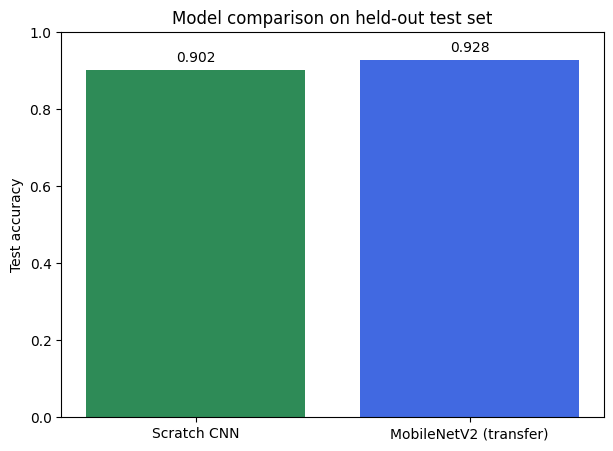

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(["Scratch CNN", "MobileNetV2 (transfer)"],
        [test_accuracy, transfer_test_accuracy],
        color=["seagreen", "royalblue"])
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.title("Model comparison on held-out test set")
for i, v in enumerate([test_accuracy, transfer_test_accuracy]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.show()


In [ ]:
cnn_model.save("fruits360_cnn_final.keras")
transfer_model.save("fruits360_mobilenetv2_final.keras")

import json
with open("class_indices.json", "w") as f:
    json.dump(test_generator.class_indices, f)

print("Saved: fruits360_cnn_final.keras, fruits360_mobilenetv2_final.keras, class_indices.json")


Saved: fruits360_cnn_final.keras, fruits360_mobilenetv2_final.keras, class_indices.json


In [ ]:
from google.colab import files

files.download("fruits360_cnn_final.keras")
files.download("fruits360_mobilenetv2_final.keras")
files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>